In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
df = pd.read_excel('cluster.xlsx')

In [31]:
df

,x1,x2
0,-2.204227,-1.915196
1,0.737962,-8.332799
2,-5.108492,-0.741470
3,-2.117262,4.238704
4,-2.233646,0.742192
...,...,...
95,4.685048,-2.911701
96,-7.240652,9.125469
97,0.713322,3.910490
98,-0.798009,-1.560285


In [35]:
X = df.values

In [36]:
from sklearn.cluster import KMeans

In [42]:
md2 = KMeans(n_clusters=2)
md2.fit(X)

KMeans(n_clusters=2)

In [57]:
md2.inertia_

2087.539513484855

In [43]:
md2.cluster_centers_[0,:]

array([ 2.56459891, -4.056239  ])

In [44]:
md2.labels_

array([0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1], dtype=int32)

In [45]:
df['labels'] = md2.labels_

In [46]:
df

,x1,x2,labels
0,-2.204227,-1.915196,0
1,0.737962,-8.332799,0
2,-5.108492,-0.741470,1
3,-2.117262,4.238704,1
4,-2.233646,0.742192,1
...,...,...,...
95,4.685048,-2.911701,0
96,-7.240652,9.125469,1
97,0.713322,3.910490,1
98,-0.798009,-1.560285,0


In [47]:
import seaborn as snc

In [53]:
# snc.pairplot(df,hue='labels')

In [50]:
!pip install mglearn --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 3.6 MB/s eta 0:00:00


In [51]:
import mglearn as mg

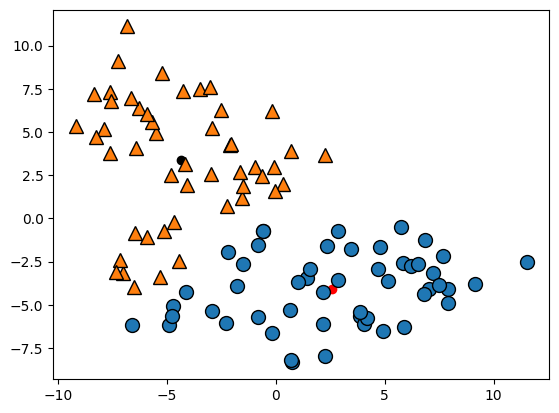

In [56]:
mg.discrete_scatter(X[:,0],X[:,1],df['labels'])
plt.scatter(md2.cluster_centers_[0,0], md2.cluster_centers_[0,1], color='red')
plt.scatter(md2.cluster_centers_[1,0], md2.cluster_centers_[1,1], color='black')

# To find the optimum number of groups

In [61]:
ls_iner = []
for k in range(1,10):
    model = KMeans(n_clusters=k)
    model.fit(X)
    ls_iner.append(model.inertia_)

In [62]:
ls_iner

[4676.604342943335,
 2094.4828775363067,
 1199.4676799533152,
 973.987150994776,
 627.7537480275282,
 542.3470076210813,
 477.31937228698183,
 421.61566708623377,
 395.9924208060367]

In [63]:
ls_k = [1,2,3,4,5,6,7,8,9]

In [64]:
for z in zip(ls_k,ls_iner):
    print(z)

(1, 4676.604342943335)
(2, 2094.4828775363067)
(3, 1199.4676799533152)
(4, 973.987150994776)
(5, 627.7537480275282)
(6, 542.3470076210813)
(7, 477.31937228698183)
(8, 421.61566708623377)
(9, 395.9924208060367)


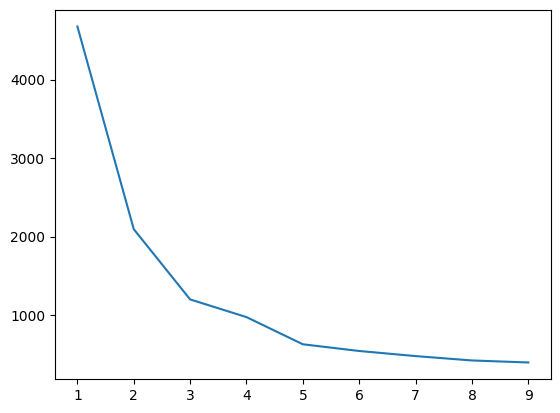

In [65]:
plt.plot(ls_k,ls_iner)

In [66]:
from sklearn.metrics import silhouette_score

In [67]:
silhouette_score(X,md2.labels_)

np.float64(0.4609433244179455)